In [152]:
import pandas as pd
import numpy as np

ozon = pd.read_csv('ozon_products.csv')
wb = pd.read_csv('wb_products.csv')
api = pd.read_csv('items_all.csv')
columns = ['sid',	'name',	'balance',	'wholesale_price', 'currency',	'category_id', 'retail_price']
api = api[columns]
api.to_csv("items_all.csv", index=False, encoding="utf-8-sig")

Задаем колнки датасета, с данными, полученными с помощью API.

In [153]:
columns = ['sid',	'name',	'balance',	'wholesale_price', 'currency',	'category_id', 'retail_price']
api = api[columns]

Удаляем дубликаты.

In [154]:
len(pd.unique(ozon['Артикул']))
ozon_unique = ozon.drop_duplicates(subset='Артикул', keep='first')
len(ozon_unique)
print(len(ozon) - len(ozon_unique), 'дубликатов среди товаров в магазине сималенда на ozon')

937 дубликатов среди товаров в магазине сималенда на ozon


In [155]:
len(wb)
wb_unique = wb.drop_duplicates(subset='Артикул', keep='first')
len(wb_unique)
print(len(wb) - len(wb_unique), 'дубликатов среди товаров в магазине сималенда на wildberries')

350 дубликатов среди товаров в магазине сималенда на wildberries


Так как регистрация товарного знака не обязательна (для старта продаж на Вайлдберриз и Озон не требуется регистрация товарного знака. Это не является требованием площадки), заменим отсутствующие значения на "NoBrand".

In [156]:
nan_count_Ozon = ozon['Бренд'].isnull().sum()
print(f"Количество NaN в столбце 'Бренд' в магазине Ozon: {nan_count_Ozon}")

nan_count_WB = wb['Бренд'].isnull().sum()
print(f"Количество NaN в столбце 'Бренд' в магазине WB: {nan_count_WB}")

ozon_unique.loc[:, 'Бренд'] = ozon_unique['Бренд'].fillna('NoBrand')
wb_unique.loc[:, 'Бренд'] = wb_unique['Бренд'].fillna('NoBrand')


Количество NaN в столбце 'Бренд' в магазине Ozon: 227
Количество NaN в столбце 'Бренд' в магазине WB: 131


Мерджим датасеты с данными парсинга товаров, которые продает сам Simaland на своих аккаунтах Ozon и Wildberries.

In [157]:
ozon_unique = ozon_unique.rename(columns={'Предмет': 'Категория'})

merged_df = pd.concat([ozon_unique, wb_unique], ignore_index=True)

merged_df['Продажи'] = (merged_df['Продажи'].str.replace('шт.', '', regex=False).str.replace(' ', '', regex=False).str.strip())

merged_df['Продажи'] = merged_df['Продажи'].astype(int)

merged_df = merged_df.sort_values(by='Продажи', ascending=False)

merged_df['Выручка'] = (merged_df['Выручка'].str.replace('₽', '', regex=False).str.replace(' ', '', regex=False).str.strip())

merged_df['Выручка'] = merged_df['Выручка'].astype(int)
pd.to_numeric(merged_df['Упущенная выручка'].astype(str).str.replace('₽','',regex=False).str.replace(r'\s+','',regex=True).str.replace(',', '.',regex=False).str.strip(), errors='coerce')

merged_df['Упущенная выручка'] = merged_df['Упущенная выручка'].astype(str).str.replace('₽', '', regex=False).str.replace(' ', '', regex=False).str.replace(',', '.', regex=False).str.strip()
merged_df['Упущенная выручка'] = merged_df['Упущенная выручка'].astype(float)

merged_df['Упущенные продажи'] = merged_df['Упущенные продажи'].astype(str).str.replace('шт.', '', regex=False).str.replace(' ', '', regex=False).str.strip().astype(int)

merged_df['Сред'] = merged_df['Сред'].astype(str).str.replace('₽', '', regex=False).str.replace(' ', '', regex=False).str.replace(',', '.', regex=False).str.strip()
merged_df['Сред'] = merged_df['Сред'].astype(float)

print(len(merged_df))
merged_df.to_csv('data.csv', index=False, encoding='utf-8-sig')

11063


In [158]:
top_mass = merged_df['Категория'].value_counts().head(10)
print("Топ-10 самых массовых категорий:")
display(top_mass)

Топ-10 самых массовых категорий:


,count
Категория,
Елочные украшения,453
фигурка светящаяся,445
электрогирлянда,401
елочные украшения,350
Фигурки,329
Ручки мебельные,161
фоторамка,153
Кошельки,146
Фоторамки,144


In [159]:
top_revenue = merged_df.groupby('Категория')['Выручка'].sum().sort_values(ascending=False).head(10)
print("Топ-10 категорий по выручке:")
display(top_revenue)

Топ-10 категорий по выручке:


,Выручка
Категория,
Елочные украшения,9652537
Фигурки,7456012
ручка мебельная,3655976
Фоторамки,3085729
Гирлянды интерьерные,3069918
Фигуры светодиодные,2544829
Светильники,2473150
Шкатулки,2414875
Подсвечники,2064196


In [160]:
top_sales = merged_df.groupby('Категория')['Продажи'].sum().sort_values(ascending=False).head(10)
print("Топ-10 категорий по продажам:")
display(top_sales)

Топ-10 категорий по продажам:


,Продажи
Категория,
Елочные украшения,36344
Фигурки,14688
Ручки мебельные,9191
Кошельки,9138
ручка мебельная,7888
Фоторамки,7737
Резинки,5511
Подсвечники,4981
Удобрения для растений,4755


Средние продажи среди категорий с наибольшей выручкой

In [161]:
avg_price_top = merged_df[merged_df['Категория'].isin(top_revenue.index)] \
    .groupby('Категория')['Сред'].mean() \
    .reindex(top_revenue.index)
avg_price_top

,Сред
Категория,
Елочные украшения,318.910088
Фигурки,684.159301
ручка мебельная,362.125294
Фоторамки,437.539861
Гирлянды интерьерные,1146.621857
Фигуры светодиодные,2176.850000
Светильники,923.090357
Шкатулки,593.541705
Подсвечники,549.841000


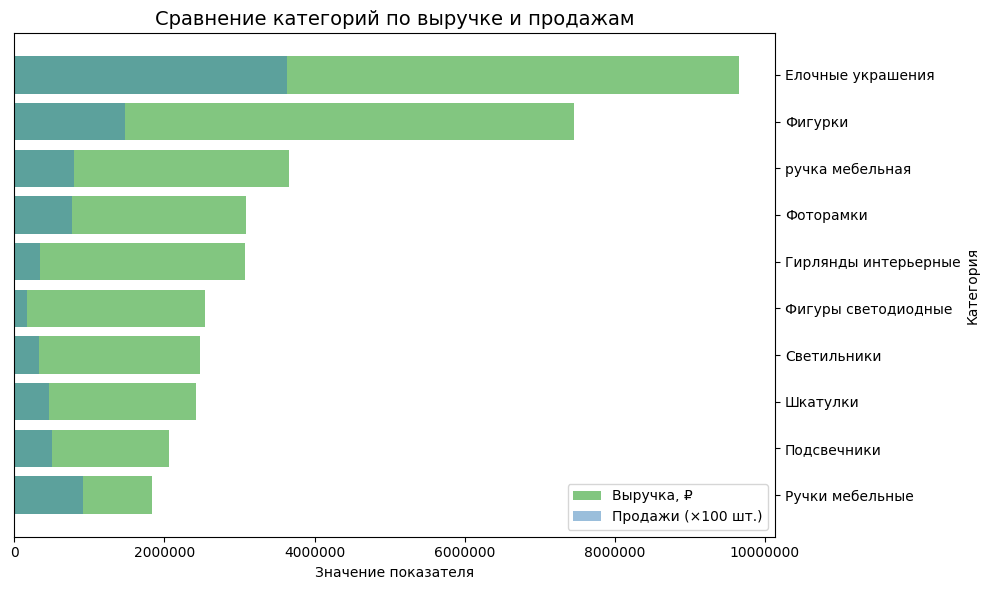

In [162]:
import matplotlib.pyplot as plt

category_stats = (
    merged_df.groupby('Категория')[['Выручка', 'Продажи']]
    .sum()
    .sort_values(by='Выручка', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(category_stats.index[::-1], category_stats['Выручка'][::-1],
         color='#4daf4a', alpha=0.7, label='Выручка, ₽')
plt.barh(category_stats.index[::-1], category_stats['Продажи'][::-1]*100,
         color='#377eb8', alpha=0.5, label='Продажи (×100 шт.)')

plt.title('Сравнение категорий по выручке и продажам', fontsize=14)
plt.xlabel('Значение показателя')
plt.ylabel('Категория')
plt.legend()
plt.ticklabel_format(style='plain', axis='x')

ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')

plt.tight_layout()
plt.show()


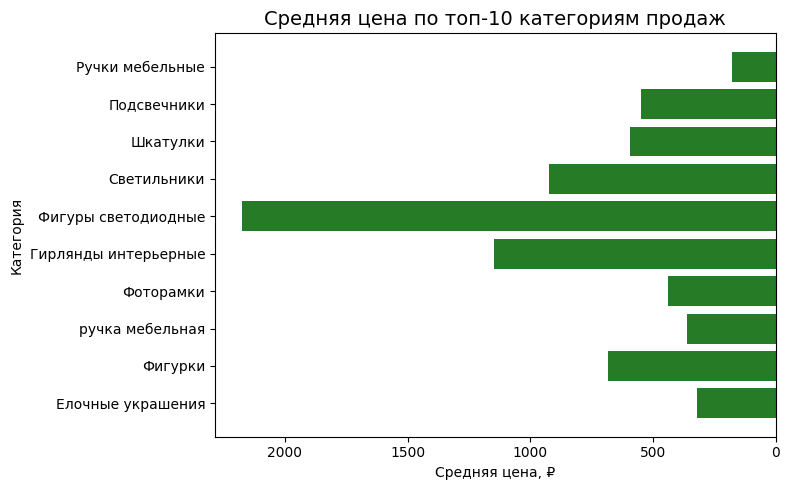

In [163]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(avg_price_top.index, avg_price_top.values, color='#006400', alpha=0.85)

plt.title('Средняя цена по топ-10 категориям продаж', fontsize=14)
plt.xlabel('Средняя цена, ₽')
plt.ylabel('Категория')

plt.gca().invert_xaxis()
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()


In [164]:
avg_price = merged_df.groupby('Категория')['Сред'].mean()
merged_df_meanprice_cat = merged_df.merge(avg_price.rename('Средняя_цена_в_категории'), on='Категория')
filtered_df = merged_df_meanprice_cat[merged_df_meanprice_cat['Продажи'] > 30].sort_values(by='Средняя_цена_в_категории', ascending=False)
filtered_df.head(10)


,Фото,Товар,Бренд,Артикул,Категория,Выручка,Продажи,Упущенная выручка,Упущенные продажи,Макс,Мин,Сред,Средняя_цена_в_категории
3216,https://basket-17.wbbasket.ru/vol2717/part2717...,Винтовка пневматическая,Baikal,271715092,Пневматическое оружие,410024,38,409626.0,39,11 300 ₽,10 770 ₽,10886.28,10886.280000
1510,https://cdn1.ozone.ru/s3/multimedia-1-l/811170...,"Елка искусственная радуга с белым 90 см, d ниж...",Зимнее волшебство,191553091,елка искусственная,45694,76,0.0,0,968 ₽,579 ₽,816.27,8298.660000
3750,https://basket-05.wbbasket.ru/vol734/part73410...,Офисный стул,Бюрократ,73410882,Кресла компьютерные,195458,32,119203.0,19,6 418 ₽,5 747 ₽,6055.67,6055.670000
3225,https://basket-08.wbbasket.ru/vol1145/part1145...,"Декоративная фигура дерево светодиодное, синий",Luazon Lighting,114525839,Светодиодные деревья,348557,38,135272.0,13,9 484 ₽,9 112 ₽,9201.21,5823.976667
2968,https://basket-16.wbbasket.ru/vol2552/part2552...,"Ветка светодиодная бежевая, 56 см, 15 LED Т БЕЛЫЙ",Luazon Lighting,255290953,Светодиодные деревья,11995,42,547.0,1,300 ₽,270 ₽,279.72,5823.976667
3826,https://basket-08.wbbasket.ru/vol1145/part1145...,Декоративная фигура дерево светодиодное,Luazon Lighting,114525840,Светодиодные деревья,280984,31,210810.0,22,9 064 ₽,9 064 ₽,9064.00,5823.976667
2796,https://basket-09.wbbasket.ru/vol1232/part1232...,"Декоративная фигура дерево светодиодное, мульти",Luazon Lighting,123242192,Светодиодные деревья,402692,44,24841.0,2,9 484 ₽,9 112 ₽,9189.82,5823.976667
3287,https://basket-04.wbbasket.ru/vol703/part70319...,Умывальник дачный с тумбой с подогревом 17 л 1...,ТЕРММИКС,70319954,Умывальники садовые,248960,37,173254.0,25,7 497 ₽,6 588 ₽,7038.56,5190.602500
3342,https://cdn1.ozone.ru/s3/multimedia-1-v/792876...,"Чайник электрический маленький дорожный ""Капел...",Sima-land,823766822,электрический чайник,31354,36,0.0,0,931 ₽,825 ₽,872.53,4270.526000
2117,https://basket-15.wbbasket.ru/vol2379/part2379...,Бак хозяйственный с крышкой 100 л,АЛЬТЕРНАТИВА,237943246,Ведра хозяйственные,222197,59,193551.0,49,3 934 ₽,3 732 ₽,3846.72,3846.720000


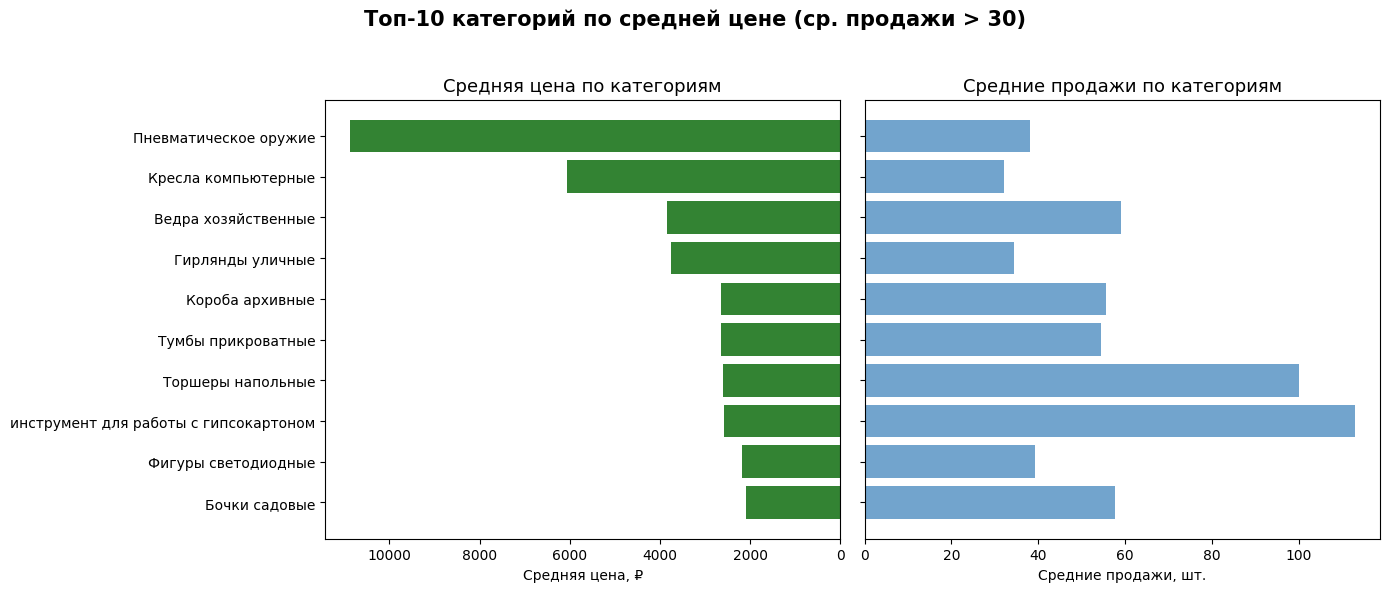

In [165]:
import matplotlib.pyplot as plt
import pandas as pd

category_stats = (
    merged_df.groupby('Категория', as_index=True)
    .agg(Средняя_цена=('Сред', 'mean'),
         Средние_продажи=('Продажи', 'mean'),
         Средняя_выручка=('Выручка', 'mean'))
)


category_stats = category_stats[category_stats['Средние_продажи'] > 30]
top10 = category_stats.nlargest(10, 'Средняя_цена')

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 6), sharey=True)

ax1.barh(top10.index, top10['Средняя_цена'], color='#006400', alpha=0.8)
ax1.set_title('Средняя цена по категориям', fontsize=13)
ax1.set_xlabel('Средняя цена, ₽')
ax1.ticklabel_format(style='plain', axis='x')
ax1.invert_yaxis()
ax1.invert_xaxis()

ax2.barh(top10.index, top10['Средние_продажи'], color='#377eb8', alpha=0.7)
ax2.set_title('Средние продажи по категориям', fontsize=13)
ax2.set_xlabel('Средние продажи, шт.')
ax2.ticklabel_format(style='plain', axis='x')

fig.suptitle('Топ-10 категорий по средней цене (ср. продажи > 30)', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



In [166]:
merged_df_lost_sales = merged_df[merged_df['Продажи'] > 30].copy()
merged_df_lost_sales = merged_df_lost_sales.sort_values(by='Упущенные продажи', ascending=False)
display(merged_df_lost_sales.head(10))

,Фото,Товар,Бренд,Артикул,Категория,Выручка,Продажи,Упущенная выручка,Упущенные продажи,Макс,Мин,Сред
9796,https://basket-10.wbbasket.ru/vol1595/part1595...,"Набор свечей хозяйственных, 4 шт, в коробке",Сималенд,159513826,Свечи,53900,603,77085.0,862,95 ₽,82 ₽,88.53
9818,https://basket-26.wbbasket.ru/vol4757/part4757...,Фигурки статуэтки зайчиков декоративные кролики,NoBrand,475725943,Статуэтки,105867,464,173706.0,764,278 ₽,206 ₽,232.59
9883,https://basket-19.wbbasket.ru/vol3221/part3221...,Невидимка для волос Тейлор (набор 36 шт) ребри...,Queen fair,322158787,Заколки клик-клак,22521,315,42228.0,598,79 ₽,66 ₽,71.49
10545,https://basket-17.wbbasket.ru/vol2738/part2738...,"Украшение ёлочное ""Балерина"" 17х7,5 см",Зимнее волшебство,273851122,Елочные украшения,21486,96,134674.0,597,228 ₽,184 ₽,212.67
10270,https://basket-15.wbbasket.ru/vol2381/part2381...,Кошелёк на молнии маленький,Сималенд,238182586,Кошельки,12184,126,59764.0,573,108 ₽,85 ₽,95.48
5284,https://basket-16.wbbasket.ru/vol2452/part2452...,Пуговицы декоративные деревянные 40шт,Арт узор,245261848,Пуговицы,7068,57,62946.0,506,124 ₽,108 ₽,116.00
9994,https://basket-17.wbbasket.ru/vol2793/part2793...,Увлажнитель воздуха мини для дома настольный с...,Luazon Home,279363181,Увлажнители,43431,206,105942.0,484,227 ₽,179 ₽,205.67
10430,https://basket-15.wbbasket.ru/vol2332/part2332...,Расчёска для волос массажная складная,Queen fair,233244856,Расчески,23604,103,117199.0,473,237 ₽,201 ₽,217.56
10997,https://basket-17.wbbasket.ru/vol2792/part2792...,Ёлочная игрушка Ангел,Luazon Lighting,279248724,Фигуры светодиодные,15168,79,110813.0,472,192 ₽,192 ₽,192.00
9985,https://basket-16.wbbasket.ru/vol2560/part2560...,Ночник Крокодильчик,RISALUX,256042346,Ночники,18024,210,39209.0,461,120 ₽,79 ₽,91.14


In [167]:
category_sales = merged_df.groupby('Категория')['Продажи'].sum()
valid_categories = category_sales[category_sales > 1000].index
filtered_df = merged_df[merged_df['Категория'].isin(valid_categories)]
lost_sales_by_category = (filtered_df.groupby('Категория')['Упущенные продажи'].sum().sort_values(ascending=False).head(10))

lost_sales_by_category



,Упущенные продажи
Категория,
Елочные украшения,7664
Фигурки,6320
Удобрения для растений,5163
Кошельки,3740
Фоторамки,3360
Резинки,3350
Статуэтки,2779
Свечи,2537
Ночники,2338


In [178]:
api['wholesale_price'] = api['wholesale_price'].astype(int)

api = api[api['wholesale_price']>100]
api_chip = api[api['balance']>50]
all_filtered = api_chip[api_chip['name'].str.contains(r'ёлочн|фигур|светильн|шкатул|фоторам|', case=False, na=False)]
print(len(all_filtered.drop_duplicates().drop_duplicates(subset='name', keep='first')))
all_filtered

api_rich_gir = api[api['balance']>10]
api_rich = api[api['balance']>5]
all_filtered_gir = api_rich_gir[api_rich_gir['name'].str.contains(r'гирлянд', case=False, na=False)]
api_rich_gir = [api['balance']>10]
all_filtered_komp = api_rich[api_rich['name'].str.contains(r'Кресло компьютерное', case=False, na=False)]



itog = all_filtered.sample(n=420).reset_index(drop=True)
df_all = pd.concat([itog, all_filtered_gir, all_filtered_komp], ignore_index=True)
df_all

2644


,sid,name,balance,wholesale_price,currency,category_id,retail_price
0,10902755,Фигурка полистоун «Ангелочек с букетом лаванды...,132.0,210,RUB,470,290.0
1,10701802,"Благовония в тубусе «Сила цветов», 30 штук с д...",133.0,179,RUB,8499,223.0
2,10896132,"Фигурка гипс «Совы говорят по телефону», 8×12×...",88.0,215,RUB,501,269.0
3,10484428,"Подвеска световая «Дед Мороз», 13×3×18 см, 6 L...",230.0,149,RUB,1050,179.0
4,4469374,"Корзинка для подачи Доляна «Плуг», 20×20×6 см,...",230.0,141,RUB,2496,185.0
...,...,...,...,...,...,...,...
595,3584290,"Гирлянда «Водопад» 2×1.5 м, IP44, прозрачная н...",15.0,2390,RUB,6339,2990.0
596,7859948,"Гирлянда «Ретро белт-лайт» 10 м, IP54, УМС, бе...",15.0,2890,RUB,6339,3290.0
597,9457564,"Кресло компьютерное офисное Chairman Home 115,...",6.0,9320,RUB,32831,10285.0
598,9457565,Кресло компьютерное офисное Chairrman Home 115...,10.0,9318,RUB,32831,10285.0
